# 01 — Exploratory Data Analysis
### Olist Brazilian E-Commerce · `retail-platform-analytics`

This notebook is the **exploratory foundation** for the project. It profiles the analytics marts
built with dbt on Snowflake, surfaces the main trends and patterns in the data, and ends with a
prioritised **analysis backlog** — the deeper analyses worth building next.

**How to read this notebook**
- Every claim is backed by a query against the marts — no assertions without data.
- Each section states the *question*, runs the query, charts it, then interprets the result.
- Jargon is defined inline the first time it appears.
- Where the data is thin or an assumption matters, I flag it explicitly as a **⚠️ Confidence note**.

**Data source:** `RETAIL_ANALYTICS.DEV_MARTS` (Snowflake) — the mart layer produced by dbt
(`dim_*`, `fct_*`, `mart_*`). Connection is handled by `db.py`, which reads credentials
from the gitignored `.env`.

## Data caveats & conventions

Read these before the analysis — they qualify every number that follows.

- **Reliable window = Jan 2017 – Aug 2018, applied throughout.** The dataset nominally spans
  Sep 2016 – Oct 2018, but the edge months (Sep–Dec 2016 ramp-in, Sep–Oct 2018 cutoff) hold only a
  handful of orders each — data-collection artefacts, not demand. **Every analysis below filters to this
  window** (via the `WINDOW` predicate defined in Setup); §2 still documents the full mart extent for
  reference. Excluding the edges moves the headline totals by <0.5% but keeps trends honest.
- **Customer identity — dbt resolves it correctly; the caveat is the source.** dbt de-duplicates the
  per-order `customer_id` to Olist's person-level `customer_unique_id` (96,096 people from 99,441 ids),
  so the mapping is sound. The residual uncertainty is whether `customer_unique_id` itself perfectly
  identifies a person (guest checkouts, one shopper under multiple ids); the source has no account/guest
  flag (nor email/document) to check or consolidate on, so the customer count may be inflated and the
  ~3% repeat rate understated.
- **Data-quality issues are handled upstream in dbt** (the intermediate layer), not here: duplicate
  `review_id`s, out-of-order delivery timestamps, and incomplete/mismatched payment rows are flagged
  or de-duplicated in `int_*` models. This notebook reads the cleaned marts.
- **No cost data.** Olist provides price and freight but no product cost, so true margin is not
  computable. Where "margin" is discussed we use freight-as-a-share-of-price as an explicit *proxy*.
- **Convention:** every query goes through `q()` (lowercases Snowflake's uppercase columns); revenue =
  `total_payment_value` on `fct_orders` unless stated; charts render inline so the notebook is
  self-contained.

## 1. Setup

We connect to Snowflake through the shared `db.py` helper. `q()` wraps it and lowercases column names.
`WINDOW` is the reliable-window SQL predicate we drop into every query so the whole notebook stays on
Jan 2017 – Aug 2018.

In [1]:
import sys
sys.path.insert(0, ".")  # db.py sits alongside this notebook in the analysis/ folder

import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    """Run SQL against Snowflake and return a DataFrame with lowercase columns."""
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

# Reliable analysis window (see caveats). Dropped into every query via an f-string. The upper bound is
# exclusive, so Sep 2018 onward and all of 2016 are excluded.
WINDOW = "purchased_at >= '2017-01-01' and purchased_at < '2018-09-01'"

print("Connected:")
print(q("select current_database() as db, current_schema() as schema, current_warehouse() as wh").to_string(index=False))

Connected:


              db    schema         wh
RETAIL_ANALYTICS DEV_MARTS COMPUTE_WH


## 2. The data landscape — what we are working with

Before analysing anything, establish the *grain* of each mart (what one row represents), its size, and
the *coverage* (how much data, over what period). One consolidated table below — grain, row count, and
use per mart.

In [2]:
# Row counts per mart (full mart extent) joined to a short description of each mart's grain.
counts = q('''
    select table_name, row_count
    from retail_analytics.information_schema.tables
    where table_schema = 'DEV_MARTS'
''')
counts["table_name"] = counts["table_name"].str.lower()   # information_schema returns UPPERCASE names
grain = pd.DataFrame([
    ("fct_orders",              "one order",           "status, delivery, payment, review"),
    ("fct_order_items",         "one line item",       "product/seller economics: price, freight"),
    ("dim_customers",           "one customer (person)", "customer location"),
    ("dim_sellers",             "one seller",          "seller location"),
    ("dim_products",            "one product",         "category, weight, dimensions"),
    ("dim_geolocation",         "one zip prefix",      "city / state lookup"),
    ("mart_customer_summary",   "one customer",        "pre-aggregated spend / behaviour"),
    ("mart_seller_performance", "one seller",          "pre-aggregated revenue / quality"),
], columns=["mart", "grain (one row =)", "use"])
landscape = grain.merge(counts.rename(columns={"table_name": "mart", "row_count": "rows"}),
                        on="mart", how="left")
landscape[["mart", "grain (one row =)", "rows", "use"]]

,mart,grain (one row =),rows,use
0,fct_orders,one order,99441,"status, delivery, payment, review"
1,fct_order_items,one line item,112650,"product/seller economics: price, freight"
2,dim_customers,one customer (person),96096,customer location
3,dim_sellers,one seller,3095,seller location
4,dim_products,one product,32951,"category, weight, dimensions"
5,dim_geolocation,one zip prefix,19015,city / state lookup
6,mart_customer_summary,one customer,96096,pre-aggregated spend / behaviour
7,mart_seller_performance,one seller,3095,pre-aggregated revenue / quality


In [3]:
# Full date coverage, plus how many orders fall inside the reliable window we actually analyse.
coverage = q(f'''
    select min(purchased_at)::date as first_order,
           max(purchased_at)::date as last_order,
           count(*)                          as orders_total,
           count_if({WINDOW})                as orders_in_window,
           count(distinct customer_id)       as customers_total
    from dev_marts.fct_orders
''')
coverage

,first_order,last_order,orders_total,orders_in_window,customers_total
0,2016-09-04,2018-10-17,99441,99092,96096


**⚠️ Confidence note — the edges.** The marts span Sep 2016 → Oct 2018, but only ~99,092 of the
99,441 orders fall inside the reliable window — the ~349 excluded orders are the sparse ramp-in/cutoff
months. From here on, **every query is windowed to Jan 2017 – Aug 2018.**

## 3. Where do orders end up? (Order status)

`status` records the terminal state of each order. This tells us how clean the dataset is and how
much of it represents completed commerce.

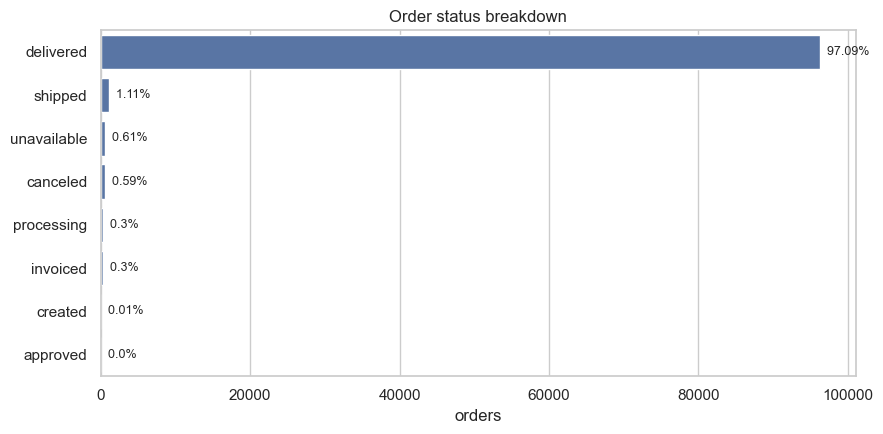

,status,orders,pct
0,delivered,96211,97.09
1,shipped,1097,1.11
2,unavailable,602,0.61
3,canceled,580,0.59
4,processing,299,0.30
5,invoiced,296,0.30
6,created,5,0.01
7,approved,2,0.00


In [4]:
status = q(f'''
    select status, count(*) as orders
    from dev_marts.fct_orders
    where {WINDOW}
    group by 1 order by 2 desc
''')
status["pct"] = (100 * status["orders"] / status["orders"].sum()).round(2)

fig, ax = plt.subplots()
sns.barplot(data=status, y="status", x="orders", ax=ax, color="#4C72B0")
ax.set_title("Order status breakdown")
ax.set_xlabel("orders"); ax.set_ylabel("")
for i, r in status.iterrows():
    ax.text(r["orders"], i, f"  {r['pct']}%", va="center", fontsize=9)
plt.tight_layout(); plt.show()
status

**Interpretation.** ~**97% of orders are `delivered`** — the dataset is overwhelmingly completed
commerce, so order-level revenue and delivery analysis is trustworthy. Non-terminal states
(`shipped`, `processing`, `invoiced`) and `canceled`/`unavailable` together are only ~3.5%. Because
delivered orders so dominate, delivery-quality metrics below are computed on `status = 'delivered'`
to avoid mixing in orders that never completed.

## 4. Revenue & order volume over time

Monthly revenue and order count over the reliable window, with **month-over-month (MoM)** growth — the
single most important context view of the platform's trajectory.

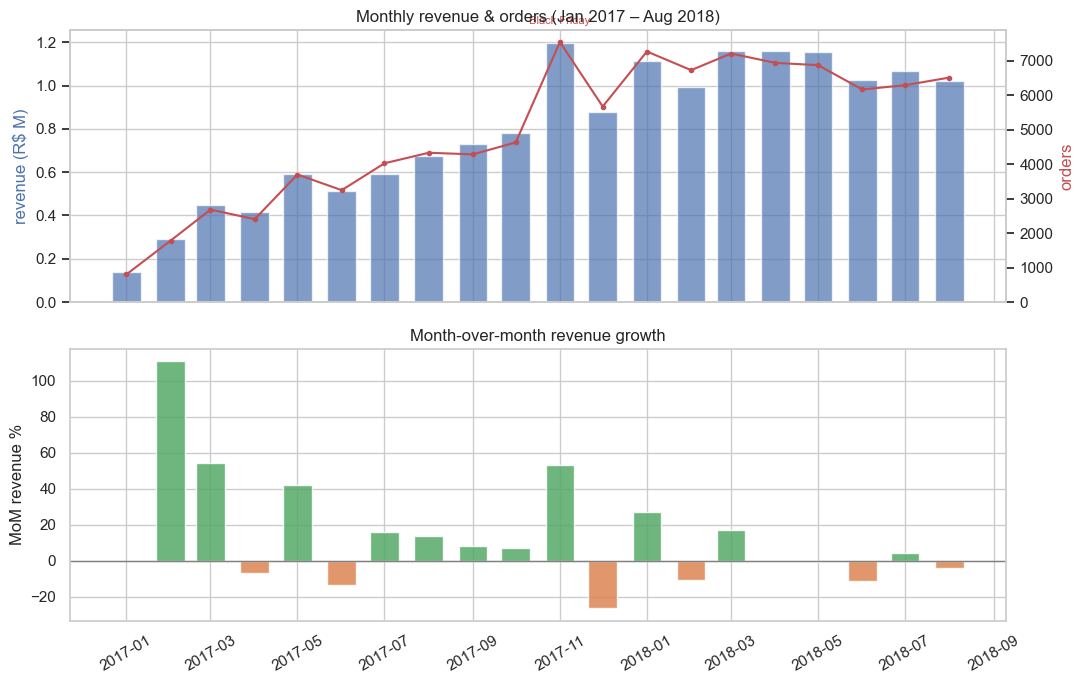

In [5]:
monthly = q(f'''
    select date_trunc('month', purchased_at)::date as month,
           count(*) as orders,
           sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    where {WINDOW}
    group by 1 order by 1
''')
monthly["month"] = pd.to_datetime(monthly["month"])            # cast Snowflake date → datetime
monthly["mom_pct"] = monthly["revenue"].pct_change() * 100     # month-over-month revenue growth

fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
# Top panel: revenue bars (left axis) + orders line (right axis). Both axes start at 0 so the
# baselines line up (otherwise the twin axes float independently and look odd).
ax1.bar(monthly["month"], monthly["revenue"] / 1e6, width=20, color="#4C72B0", alpha=0.7)
ax1.set_ylabel("revenue (R$ M)", color="#4C72B0"); ax1.set_ylim(bottom=0)
ax1.set_title("Monthly revenue & orders (Jan 2017 – Aug 2018)")
ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["orders"], color="#C44E52", marker="o", ms=3)
ax2.set_ylabel("orders", color="#C44E52"); ax2.set_ylim(bottom=0); ax2.grid(False)
bf = monthly.loc[monthly["month"] == pd.Timestamp("2017-11-01")]
if len(bf):
    ax1.annotate("Black Friday", xy=(bf["month"].iloc[0], bf["revenue"].iloc[0] / 1e6),
                 xytext=(0, 14), textcoords="offset points", ha="center", fontsize=8, color="#C44E52")
# Bottom panel: month-over-month % change (green up / orange down).
colors = ["#55A868" if v >= 0 else "#DD8452" for v in monthly["mom_pct"].fillna(0)]
ax3.bar(monthly["month"], monthly["mom_pct"], width=20, color=colors, alpha=0.85)
ax3.axhline(0, color="grey", lw=1)
ax3.set_ylabel("MoM revenue %"); ax3.set_title("Month-over-month revenue growth")
ax3.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

**Interpretation.** Revenue grew **~4×** across the window — from ~R$138k (Jan 2017) to a
~R$1M/month run-rate by 2018. The **MoM panel** shows the ride is bumpy: a **+53% Black-Friday jump
(Nov 2017)** followed by a −27% December give-back, and 2018 months oscillating around flat — the
signature of a **maturing base** (big early gains, then plateau). All figures use the reliable window,
so there is no fake ramp-in or cutoff to explain away.

### Quarterly revenue & quarter-on-quarter (QoQ) growth

Aggregating to quarters smooths the monthly noise and reads the growth *rate*. **QoQ growth** = percent
change in revenue vs the previous quarter. We use **complete quarters only** — 2018 Q3 is excluded
because only July–August fall inside the window (September is the cutoff), so it is mechanically
incomplete and would show a false −39% drop. We don't extrapolate it.

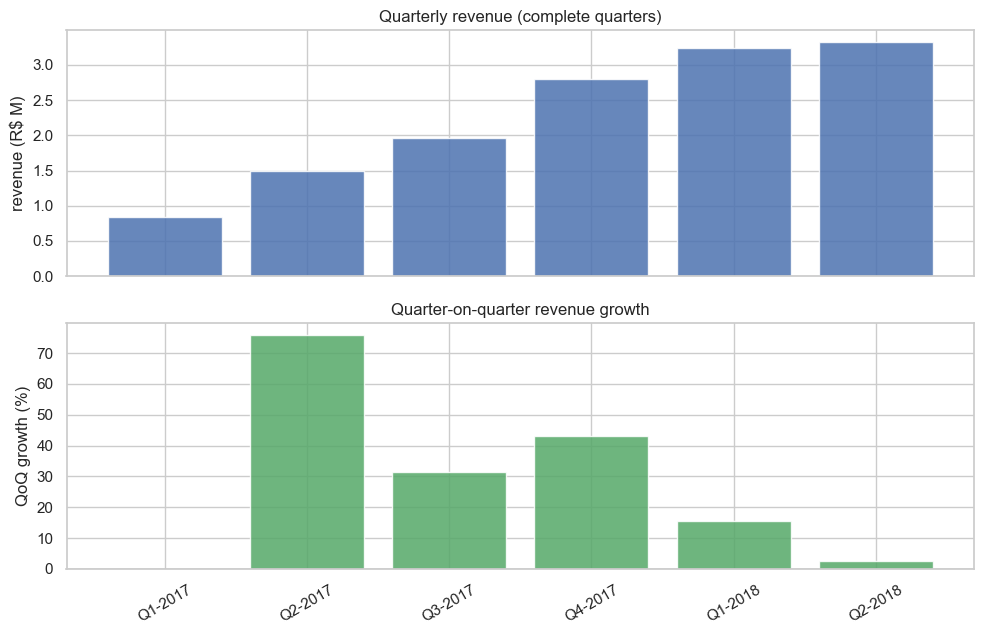

,period,revenue,qoq_growth_pct
0,Q1-2017,"846,285.10",NaN
1,Q2-2017,"1,488,742.00",75.90
2,Q3-2017,"1,958,125.60",31.50
3,Q4-2017,"2,799,339.00",43.00
4,Q1-2018,"3,235,342.40",15.60
5,Q2-2018,"3,322,546.80",2.70


In [6]:
qoq = q('''
    select concat('Q', quarter(purchased_at), '-', year(purchased_at)) as period,
           year(purchased_at) as yr, quarter(purchased_at) as qtr,
           sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    where status not in ('canceled', 'unavailable')
      and purchased_at >= '2017-01-01' and purchased_at < '2018-07-01'   -- complete quarters only
    group by 1, 2, 3 order by 2, 3
''')
qoq["qoq_growth_pct"] = qoq["revenue"].pct_change() * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
ax1.bar(qoq["period"], qoq["revenue"] / 1e6, color="#4C72B0", alpha=0.85)
ax1.set_ylabel("revenue (R$ M)"); ax1.set_title("Quarterly revenue (complete quarters)")
g = qoq.dropna(subset=["qoq_growth_pct"])
colors = ["#55A868" if v >= 0 else "#DD8452" for v in g["qoq_growth_pct"]]
ax2.bar(g["period"], g["qoq_growth_pct"], color=colors, alpha=0.85)
ax2.axhline(0, color="grey", lw=1)
ax2.set_ylabel("QoQ growth (%)"); ax2.set_title("Quarter-on-quarter revenue growth")
ax2.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
qoq[["period", "revenue", "qoq_growth_pct"]].round(1)

**Interpretation.** Over complete quarters, growth is strong but **decelerating as the base
matures** — a healthy S-curve: **+76% (Q2-17) → +31% → +43% (the Black-Friday quarter) → +16% (Q1-18)
→ +2.7% (Q2-18)**. The rate falls as the denominator grows: the platform is maturing, not stalling.

## 5. Delivery performance

**Why look at delivery?** It's the platform's core operational promise — and Section 9 will show it is
the **single biggest driver of review scores** — so we first profile *how long* delivery takes and *how
it compares to the estimate shown at checkout*. (Estimate accuracy by route/region is dissected in
notebook `02`.)

- **`delivery_time_days`** = days from purchase to delivery to the customer.
- **On-time** = delivered on or before `estimated_delivery_date` (the estimate shown at checkout).

In [7]:
deliv = q(f'''
    select count(*) as delivered,
           avg(delivery_time_days)  as avg_days,
           median(delivery_time_days) as median_days,
           avg(iff(is_delivered_on_time, 1, 0)) * 100 as on_time_pct
    from dev_marts.fct_orders
    where status = 'delivered' and delivery_time_days is not null and {WINDOW}
''')
deliv

,delivered,avg_days,median_days,on_time_pct
0,96203,12.48,10.00,91.87


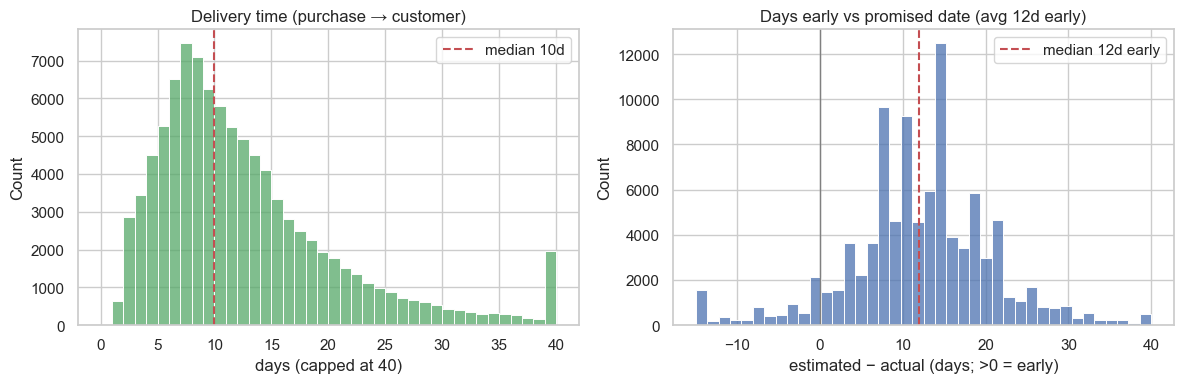

In [8]:
# Two distributions. Left: delivery time, capped at 40 days — a long right tail of slow deliveries
# would otherwise squash the bulk of the mass into the left edge. Right: the "buffer" = days the order
# arrived BEFORE the promised date (estimated - actual; >0 = early), capped to a readable range.
dist = q(f'''
    select least(delivery_time_days, 40) as days,
           greatest(least(datediff('day', delivered_to_customer_at, estimated_delivery_date), 40), -15) as days_early
    from dev_marts.fct_orders
    where status = 'delivered' and delivery_time_days between 0 and 200 and {WINDOW}
''')
avg_early = q(f'''select avg(datediff('day', delivered_to_customer_at, estimated_delivery_date)) as p
    from dev_marts.fct_orders
    where status = 'delivered' and delivered_to_customer_at is not null and {WINDOW}''').iloc[0, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(dist["days"], bins=40, color="#55A868", ax=ax1)
ax1.axvline(dist["days"].median(), color="#C44E52", ls="--", label=f"median {dist['days'].median():.0f}d")
ax1.set_title("Delivery time (purchase → customer)"); ax1.set_xlabel("days (capped at 40)"); ax1.legend()
sns.histplot(dist["days_early"], bins=40, color="#4C72B0", ax=ax2)
ax2.axvline(0, color="grey", lw=1)
ax2.axvline(dist["days_early"].median(), color="#C44E52", ls="--", label=f"median {dist['days_early'].median():.0f}d early")
ax2.set_title(f"Days early vs promised date (avg {avg_early:.0f}d early)")
ax2.set_xlabel("estimated − actual (days; >0 = early)"); ax2.legend()
plt.tight_layout(); plt.show()

**Interpretation.** Median delivery is **~10 days**, mean **~12.5 days** — the right-skew of slow
deliveries pulls the mean above the median (hence the 40-day display cap, so the bulk stays legible).
**~92% of orders arrive on time**, and the right panel shows *why*: orders land on average **~12 days
before** the promised date. Olist's checkout estimates are **deliberately conservative** (under-promise,
over-deliver) — the estimate is a comfortable buffer, not a tight SLA. *(Notebook `02` shows some remote
states get much thinner buffers and miss more often.)*

## 6. Geographic concentration

Brazil is large and unevenly populated. `delivery_state` is the two-letter state code of the delivery
address (e.g. **SP** = São Paulo, **RJ** = Rio de Janeiro, **MG** = Minas Gerais).

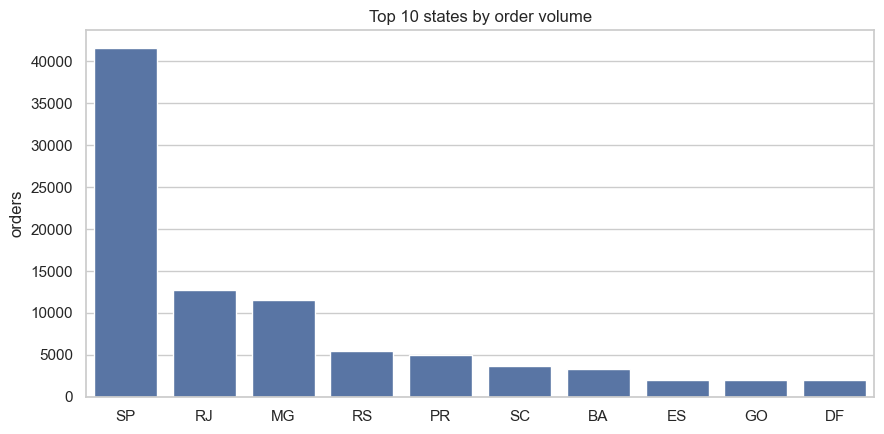

,state,orders,revenue,order_share_pct
0,SP,41606,"5,975,674.70",46.50
1,RJ,12779,"2,128,620.86",14.30
2,MG,11580,"1,864,847.39",13.00
3,RS,5437,"885,794.12",6.10
4,PR,5014,"807,680.18",5.60
5,SC,3625,"619,941.97",4.10
6,BA,3367,"614,208.28",3.80
7,ES,2023,"324,423.53",2.30
8,GO,2002,"348,154.07",2.20
9,DF,1963,"324,895.70",2.20


In [9]:
geo = q(f'''
    select delivery_state as state, count(*) as orders, sum(total_payment_value) as revenue
    from dev_marts.fct_orders
    where {WINDOW}
    group by 1 order by 2 desc limit 10
''')
geo["order_share_pct"] = (100 * geo["orders"] / geo["orders"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=geo, x="state", y="orders", ax=ax, color="#4C72B0", order=geo["state"])
ax.set_title("Top 10 states by order volume"); ax.set_xlabel(""); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()
geo

**Interpretation.** Demand is **heavily concentrated in the Southeast**. **São Paulo (SP) alone is
~42% of all orders** and revenue; the top three states (SP, RJ, MG) together are the majority of the
platform. This concentration matters for later analysis: national averages are effectively
*SP averages*, and delivery/logistics performance will be dominated by the Southeast corridor. Any
regional insight should be read against this base-rate skew.

## 7. Product categories & revenue concentration (Pareto)

Which categories drive revenue, at what price point, and how concentrated is that revenue? The **Pareto
principle** ("80/20 rule") predicts a small share of categories drives most revenue — we test it.

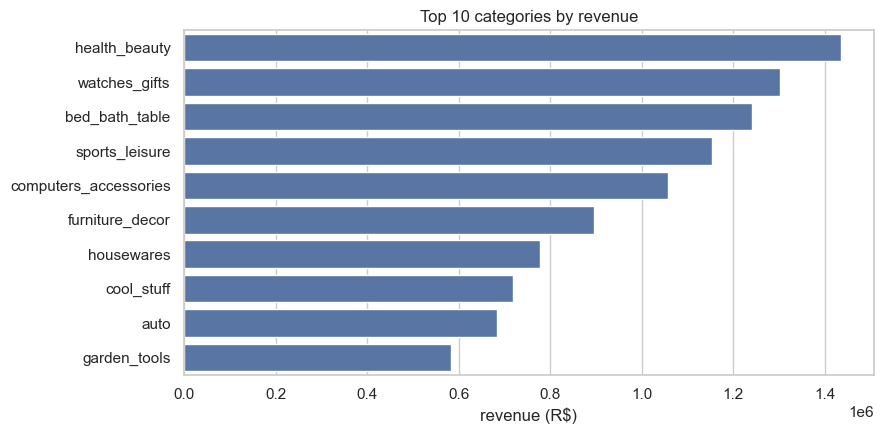

,category_name,revenue,items,avg_price,pct
0,health_beauty,"1,435,611.20",9619,130.40,9.20
1,watches_gifts,"1,302,073.60",5986,200.70,8.40
2,bed_bath_table,"1,241,075.10",11107,93.30,8.00
3,sports_leisure,"1,152,729.40",8622,114.20,7.40
4,computers_accessories,"1,057,532.30",7806,116.60,6.80
5,furniture_decor,"895,323.30",8265,87.60,5.70
6,housewares,"776,855.20",6952,90.80,5.00
7,cool_stuff,"718,002.80",3788,167.40,4.60
8,auto,"683,126.80",4223,139.90,4.40
9,garden_tools,"582,754.00",4342,111.40,3.70


In [10]:
cats = q(f'''
    select oi.category_name,
           sum(oi.total_item_value) as revenue,
           count(*)                 as items,
           avg(oi.price)            as avg_price
    from dev_marts.fct_order_items oi
    join dev_marts.fct_orders o on oi.order_id = o.order_id
    where oi.category_name is not null and {WINDOW}
    group by 1 order by 2 desc
''')
cats["pct"] = (100 * cats["revenue"] / cats["revenue"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=cats.head(10), y="category_name", x="revenue", ax=ax, color="#4C72B0")
ax.set_title("Top 10 categories by revenue"); ax.set_xlabel("revenue (R$)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()
cats.head(10)[["category_name", "revenue", "items", "avg_price", "pct"]].round(1)

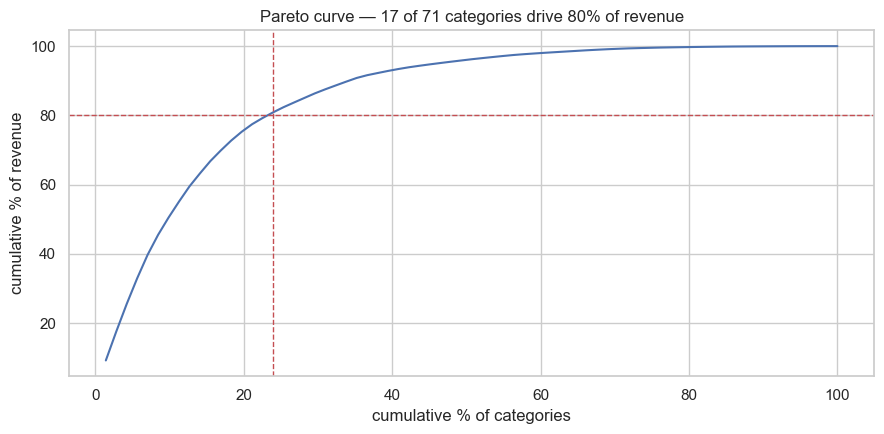

17 categories (24% of 71) = 80% of revenue


In [11]:
# Pareto curve: cumulative revenue share vs cumulative share of categories
cats_sorted = cats.sort_values("revenue", ascending=False).reset_index(drop=True)
cats_sorted["cum_rev_pct"] = 100 * cats_sorted["revenue"].cumsum() / cats_sorted["revenue"].sum()
cats_sorted["cat_rank_pct"] = 100 * (cats_sorted.index + 1) / len(cats_sorted)
n_to_80 = int((cats_sorted["cum_rev_pct"] <= 80).sum()) + 1

fig, ax = plt.subplots()
ax.plot(cats_sorted["cat_rank_pct"], cats_sorted["cum_rev_pct"], color="#4C72B0")
ax.axhline(80, color="#C44E52", ls="--", lw=1)
ax.axvline(100 * n_to_80 / len(cats_sorted), color="#C44E52", ls="--", lw=1)
ax.set_title(f"Pareto curve — {n_to_80} of {len(cats_sorted)} categories drive 80% of revenue")
ax.set_xlabel("cumulative % of categories"); ax.set_ylabel("cumulative % of revenue")
plt.tight_layout(); plt.show()
print(f"{n_to_80} categories ({100*n_to_80/len(cats_sorted):.0f}% of {len(cats_sorted)}) = 80% of revenue")

**Interpretation.** Revenue is **broad, not dominated by one category** — the top category
(`health_beauty`) is only ~9%. But concentration still holds roughly to the 80/20 rule: **~17 of ~70
categories (~24%) generate 80% of revenue**. The **avg-price** column also shows two archetypes:
*high-price / low-volume* (`watches_gifts` ~R$200, `cool_stuff` ~R$167) vs *low-price / high-volume*
(`bed_bath_table` ~R$93, `housewares` ~R$91). *(We run this same 80/20 concentration test on the
**customer** base in §10 — with a very different result.)*

*Deferred to a future notebook:* **category momentum** — which categories are *growing vs declining*
over time — needs a monthly-by-category time series and is worth its own analysis.

### Freight as a margin proxy

Olist provides price and freight but **no product-cost data**, so true margin cannot be computed.
**Freight as a share of item price** (`freight ÷ price`) is a usable *proxy* for margin pressure. We
track it across complete quarters to see whether shipping is eating a growing share of revenue.

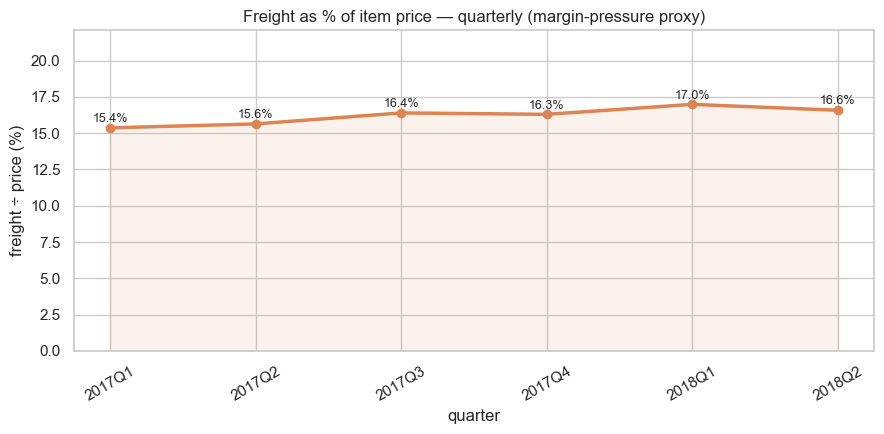

,label,freight_pct
0,2017Q1,15.40
1,2017Q2,15.60
2,2017Q3,16.40
3,2017Q4,16.30
4,2018Q1,17.00
5,2018Q2,16.60


In [12]:
freight_q = q('''
    select date_trunc('quarter', o.purchased_at)::date as quarter,
           sum(i.freight_value) as total_freight,
           sum(i.price)         as total_price,
           100.0 * sum(i.freight_value) / sum(i.price) as freight_pct
    from dev_marts.fct_orders o
    join dev_marts.fct_order_items i on o.order_id = i.order_id
    where o.status not in ('canceled', 'unavailable')
      and o.purchased_at >= '2017-01-01' and o.purchased_at < '2018-07-01'   -- complete quarters
    group by 1 order by 1
''')
freight_q["label"] = pd.to_datetime(freight_q["quarter"]).dt.to_period("Q").astype(str)

fig, ax = plt.subplots()
ax.plot(freight_q["label"], freight_q["freight_pct"], color="#DD8452", lw=2.5, marker="o")
ax.fill_between(range(len(freight_q)), freight_q["freight_pct"], alpha=0.1, color="#DD8452")
for i, v in enumerate(freight_q["freight_pct"]):
    ax.text(i, v + 0.4, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_title("Freight as % of item price — quarterly (margin-pressure proxy)")
ax.set_xlabel("quarter"); ax.set_ylabel("freight ÷ price (%)")
ax.set_ylim(0, freight_q["freight_pct"].max() * 1.3)
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()
freight_q[["label", "freight_pct"]].round(1)

**Interpretation.** Across complete quarters, freight runs a **stable ~15–17% of item price**, with
a **mild upward drift** — from ~15% in early 2017 to ~17% by mid-2018. So shipping consistently absorbs
roughly one-sixth of gross sale value, and that burden is inching up, not exploding. The deeper question
— *which categories* carry the heaviest freight drag — is the subject of notebook `04`.

**⚠️ Confidence note.** This is a **proxy, not real margin** (no cost data).

## 8. Payment behaviour

`primary_payment_type` is the dominant payment method per order. Two Brazil-specific notes:
- **`boleto`** = *boleto bancário*, a cash/bank-slip voucher paid at a bank or lottery agent — popular
  with customers who lack or avoid credit cards. It is paid in a single lump (no instalments).
- **`installments`** = the number of monthly instalments the payment is split into (common on credit
  cards in Brazil, even for small purchases).

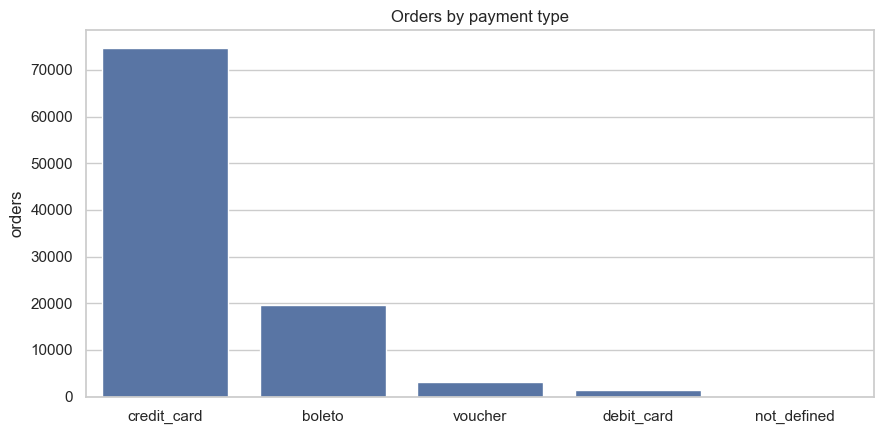

,type,orders,avg_installments,aov,order_share_pct
0,credit_card,74721,3.55,167.21,75.40
1,boleto,19721,1.00,145.01,19.90
2,voucher,3123,1.15,119.45,3.20
3,debit_card,1525,1.00,142.75,1.50
4,not_defined,2,1.00,0.00,0.00


In [13]:
pay = q(f'''
    select primary_payment_type as type, count(*) as orders,
           avg(installments) as avg_installments,
           avg(total_payment_value) as aov
    from dev_marts.fct_orders
    where primary_payment_type is not null and total_payment_value is not null and {WINDOW}
    group by 1 order by 2 desc
''')
pay["order_share_pct"] = (100 * pay["orders"] / pay["orders"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=pay, x="type", y="orders", ax=ax, color="#4C72B0")
ax.set_title("Orders by payment type"); ax.set_xlabel(""); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()
pay

**Interpretation.** **Credit card dominates (~75%)** and is the only method with meaningful
instalment use (**~3.6 instalments on average**), whereas boleto (~20%) is always paid in one lump.
Credit-card orders also carry a **higher average order value** (R$167 vs R$145 for boleto) — instalments
let customers commit to larger baskets. The `not_defined`/null rows are a tiny handful (documented as a
known data-quality issue in the dbt layer).

## 9. Customer satisfaction (reviews)

`review_score` is a 1–5 rating left after the order. We look at the distribution and, crucially, test
the hypothesis that **late delivery drives low scores**.

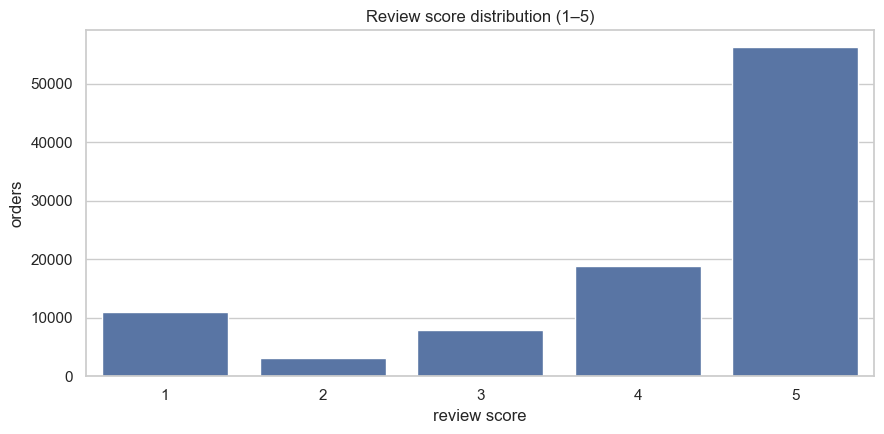

,review_score,n,pct
0,1,11020,11.30
1,2,3062,3.20
2,3,7976,8.20
3,4,18807,19.40
4,5,56275,57.90


In [14]:
rev = q(f'''
    select review_score, count(*) as n
    from dev_marts.fct_orders
    where review_score is not null and {WINDOW}
    group by 1 order by 1
''')
fig, ax = plt.subplots()
sns.barplot(data=rev, x="review_score", y="n", ax=ax, color="#4C72B0")
ax.set_title("Review score distribution (1–5)"); ax.set_xlabel("review score"); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()
rev["pct"] = (100 * rev["n"] / rev["n"].sum()).round(1)
rev

In [15]:
rev_ontime = q(f'''
    select is_delivered_on_time, avg(review_score) as avg_score, count(*) as n
    from dev_marts.fct_orders
    where review_score is not null and is_delivered_on_time is not null and status = 'delivered' and {WINDOW}
    group by 1 order by 1
''')
rev_ontime

,is_delivered_on_time,avg_score,n
0,False,2.57,7563
1,True,4.30,86889


**Interpretation.** Scores are **bimodal, skewed positive**: ~58% are 5-star, but 1-star is the
second-largest bucket (~11%) — customers rate when delighted *or* burned. The delivery split is the
headline finding of this notebook:

> **On-time orders average 4.30★; late orders average 2.57★** — a **1.7-point** collapse.

Late delivery is the single clearest satisfaction killer in the data. This is the strongest candidate
for a deeper driver analysis (Section 12), built out in notebook `02`.

**⚠️ Confidence note.** This is a correlation, not a controlled test — late orders may differ in other
ways (heavier items, remote states). Notebook `02` adds the controls a proper driver model needs.

## 10. Customer behaviour — repeat rate & spend concentration

Two questions: do customers come back, and how concentrated is spend? Computed **within the reliable
window**, directly from orders (not the lifetime `mart_customer_summary`), so they're consistent with
the rest of the notebook. Identity is Olist's person-level id — see the note at the end.

In [16]:
# One row per customer, aggregated over their orders inside the window.
custw = q(f'''
    select o.customer_id,
           count(distinct o.order_id) as orders,
           sum(o.total_payment_value) as spend
    from dev_marts.fct_orders o
    where {WINDOW}
    group by 1
''')
for c in ["orders", "spend"]:
    custw[c] = pd.to_numeric(custw[c], errors="coerce")
repeat_pct = 100 * (custw["orders"] >= 2).mean()
print(f"{len(custw):,} customers | repeat rate {repeat_pct:.1f}% | "
      f"avg spend R${custw['spend'].mean():.0f} | median spend R${custw['spend'].median():.0f}")

95,774 customers | repeat rate 3.1% | avg spend R$166 | median spend R$108


**How many orders does each customer place?** Almost all place exactly one:

In [17]:
orders_per_cust = (custw["orders"].value_counts().sort_index()
                   .rename_axis("orders_per_customer").reset_index(name="customers"))
orders_per_cust.head()

,orders_per_customer,customers
0,1,92799
1,2,2728
2,3,198
3,4,30
4,5,8


**How concentrated is spend? (Customer Pareto.)** We repeat Section 7's 80/20 test on the customer
base: sort customers by spend (highest first) and plot the cumulative share of revenue. A steep curve
means a few customers dominate; a near-diagonal means spend is spread evenly.

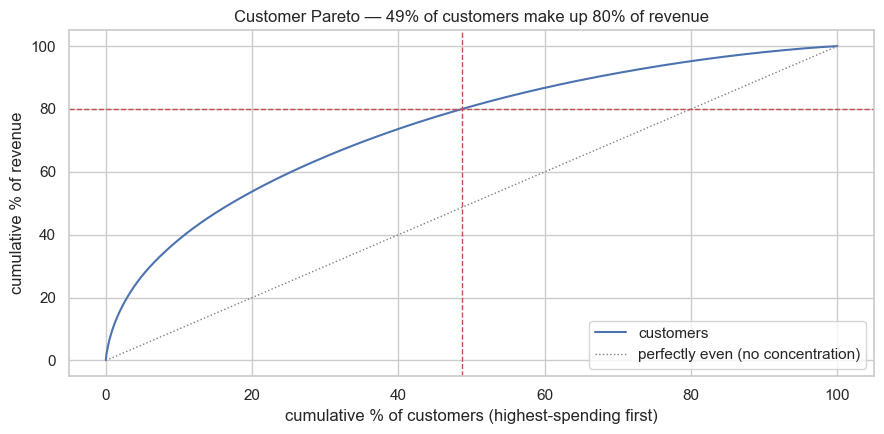

Top 10% of customers = 39% of revenue | top 20% = 54% | 80% of revenue needs ~49% of customers


In [18]:
# Customer Pareto: cumulative revenue vs cumulative share of customers (highest-spending first).
# Mirrors the category Pareto in Section 7 — do a few customers drive most of the revenue?
spend_sorted = custw["spend"].sort_values(ascending=False).to_numpy()
cum_rev = 100 * np.cumsum(spend_sorted) / spend_sorted.sum()
cum_cust = 100 * np.arange(1, len(spend_sorted) + 1) / len(spend_sorted)
pct_cust_for_80 = cum_cust[np.searchsorted(cum_rev, 80)]   # % of customers needed to reach 80% revenue

fig, ax = plt.subplots()
ax.plot(cum_cust, cum_rev, color="#4C72B0", label="customers")
ax.plot([0, 100], [0, 100], color="grey", ls=":", lw=1, label="perfectly even (no concentration)")
ax.axhline(80, color="#C44E52", ls="--", lw=1)
ax.axvline(pct_cust_for_80, color="#C44E52", ls="--", lw=1)
ax.set_title(f"Customer Pareto — {pct_cust_for_80:.0f}% of customers make up 80% of revenue")
ax.set_xlabel("cumulative % of customers (highest-spending first)")
ax.set_ylabel("cumulative % of revenue"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
top10 = cum_rev[int(0.10 * len(cum_rev)) - 1]; top20 = cum_rev[int(0.20 * len(cum_rev)) - 1]
print(f"Top 10% of customers = {top10:.0f}% of revenue | top 20% = {top20:.0f}% | "
      f"80% of revenue needs ~{pct_cust_for_80:.0f}% of customers")

**Interpretation.** Olist is an **acquisition-driven, one-and-done marketplace**: only **~3.1% of
customers place a second order** within the window — ~93k of ~96k buy exactly once. And here's the twist:
unlike product categories (§7 — ~24% of categories drive 80% of revenue) and sellers (§11 — the top 10%
earn ~two-thirds), **the customer base is *not* Pareto-concentrated.** It takes **~49% of customers to
reach 80% of revenue** (the top decile is only ~38%) — the curve hugs the diagonal. The 80/20 rule holds
for *what* is bought and *who* sells, but **not for *who* buys**, because almost everyone buys once with
a similar basket.

**⚠️ Note — identity is resolved correctly; the caveat is at the source.** dbt already de-duplicates to
Olist's person-level `customer_unique_id` (`dim_customers` holds one row per person — 96,096 from 99,441
per-order ids), so the dedup itself is **not** in doubt. What we *cannot* verify is whether
`customer_unique_id` perfectly identifies a real person: **guest checkouts**, or one shopper appearing
under several unique-ids, would inflate the customer count and understate repeat — and the source has
**no account/guest flag** (nor email/document/phone) to consolidate on. So read ~3% as a floor.

## 11. Seller performance

Marketplaces typically show a power-law: a few sellers drive most volume. We test that (recomputed
within the window from order items) and check whether faster sellers earn better reviews.

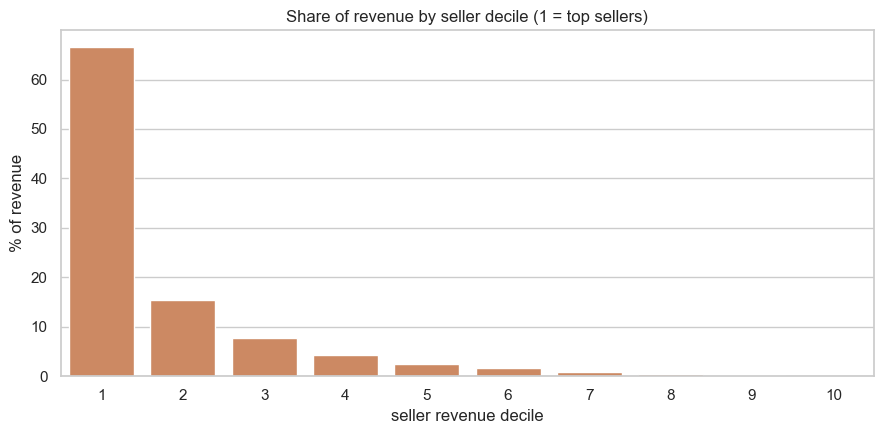

Top 10% of sellers = 66.6% of revenue


In [19]:
seller_conc = q(f'''
    with s as (
        select oi.seller_id, sum(oi.total_item_value) as revenue
        from dev_marts.fct_order_items oi
        join dev_marts.fct_orders o on oi.order_id = o.order_id
        where {WINDOW}
        group by 1),
    r as (select revenue, ntile(10) over (order by revenue desc) as decile from s)
    select decile, sum(revenue) as revenue from r group by 1 order by 1
''')
seller_conc["rev_share_pct"] = (100 * seller_conc["revenue"] / seller_conc["revenue"].sum()).round(1)

fig, ax = plt.subplots()
sns.barplot(data=seller_conc, x="decile", y="rev_share_pct", ax=ax, color="#DD8452")
ax.set_title("Share of revenue by seller decile (1 = top sellers)")
ax.set_xlabel("seller revenue decile"); ax.set_ylabel("% of revenue")
plt.tight_layout(); plt.show()
print(f"Top 10% of sellers = {seller_conc.loc[seller_conc['decile'] == 1, 'rev_share_pct'].iloc[0]}% of revenue")

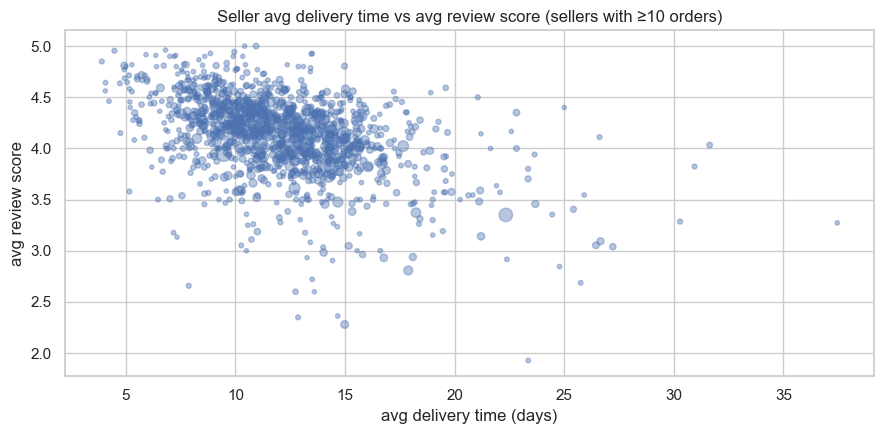

Correlation (delivery days vs review score): -0.45


In [20]:
# Do faster sellers get better reviews? Seller-level aggregates within the window, ≥10 orders.
sp = q(f'''
    with si as (
        select oi.seller_id, o.order_id, o.delivery_time_days, o.review_score
        from dev_marts.fct_order_items oi
        join dev_marts.fct_orders o on oi.order_id = o.order_id
        where o.status = 'delivered' and {WINDOW})
    select seller_id, count(distinct order_id) as total_orders,
           avg(delivery_time_days) as avg_delivery_time_days,
           avg(review_score)       as avg_review_score
    from si group by 1 having count(distinct order_id) >= 10
''')
fig, ax = plt.subplots()
ax.scatter(sp["avg_delivery_time_days"], sp["avg_review_score"],
           s=np.sqrt(sp["total_orders"]) * 3, alpha=0.4, c="#4C72B0")
ax.set_title("Seller avg delivery time vs avg review score (sellers with ≥10 orders)")
ax.set_xlabel("avg delivery time (days)"); ax.set_ylabel("avg review score")
plt.tight_layout(); plt.show()
print("Correlation (delivery days vs review score):",
      round(sp["avg_delivery_time_days"].corr(sp["avg_review_score"]), 3))

**Interpretation.** The seller side is a **classic power-law**: the **top 10% of sellers generate
~two-thirds of revenue**, and the bottom half is negligible. The scatter reinforces Section 9 at the
seller level — sellers with **slower average delivery trend toward lower review scores** (negative
correlation). Delivery speed is a seller-quality lever, not just a logistics stat.

## 12. Findings & analysis backlog

### What the data says (reliable window, Jan 2017 – Aug 2018)
1. **Growth business, ~97% delivered.** Revenue ~4× from early-2017 to 2018 with a Nov-2017
   Black-Friday spike, then a maturing plateau (QoQ decelerating to low single digits).
2. **Delivery reliability is the satisfaction lever.** ~92% on-time; on-time orders average **4.30★**
   vs **2.57★** for late — a 1.7-point swing. Confirmed again at the seller level.
3. **Under-promise / over-deliver logistics.** Orders arrive ~12 days *earlier* than the checkout
   estimate on average — estimates are conservative buffers, not tight SLAs.
4. **Heavy geographic concentration.** São Paulo ≈ 42% of orders; the Southeast dominates.
5. **Broad category revenue, mild Pareto.** No single category >9%; ~17 of ~70 categories = 80% revenue.
6. **Credit card + instalments culture.** ~75% credit card, ~3.6 instalments avg, higher AOV than the
   single-lump boleto (~20%).
7. **One-and-done customers, power-law sellers.** ~3% customer repeat rate (a floor — see the identity
   note); top 10% of sellers ≈ two-thirds of revenue.

### Analysis backlog — what to build next
| # | Analysis | Builds on | Status |
|---|---|---|---|
| A | **Delivery-lateness driver** — review-score impact of lateness, controlling for distance/weight/category | §5, §9, §11 | built → `02` |
| B | **Estimate-accuracy / SLA by route** — where and by how much are estimates off? | §5 | built → `02` |
| D | **Geographic delivery equity** — delivery time & on-time rate by state / distance | §6, §11 | built → `02` |
| — | **Customer value & behaviour** — what makes a customer valuable (price-point), and why repeat is low | §10 | built → `03` |
| E | **Category & freight economics** — freight-as-margin-proxy by category and weight | §7 | built → `04` |
| F | **Category momentum & cohort retention** — rising/declining categories; acquisition cohorts over time | §4, §7, §10 | **open** (needs a live/incremental pipeline for true time-series) |

**Most defensible signal:** delivery reliability → satisfaction (§5/§9), which anchored notebook `02`.
The remaining open work (category momentum, cohort retention) needs time-series the static snapshot
can't fully support.